In [30]:
%%capture
%load_ext autoreload
%autoreload 2

In [35]:
import sys
sys.path.append('../utils')

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from reporting import performance_report

plt.style.use('../utils/plot-style.rc')

In [36]:
prices         = pd.read_parquet('../data/monthly-etf-prices.parquet')
returns        = prices.pct_change().dropna(how='all')

excess_returns = returns - returns['BIL'].values.reshape(-1,1) # use BIL as risk free rate
excess_returns = excess_returns.drop(columns=['BIL'])

### Look at SPY Alone

[]

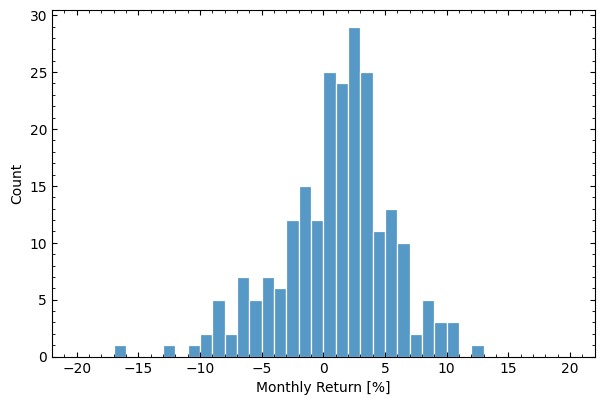

In [33]:
#### not sure if this is useful... could be cool to do a 2D kde plot of returns to see correlation
fig, ax = plt.subplots()
sns.histplot(returns['SPY'] * 100, edgecolor='w', bins=np.arange(-20,21,1))
# sns.kdeplot(returns['SPY'] * 100, fill=True, zorder=10)
ax.set_xlabel('Monthly Return [%]')
plt.plot()

     CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
--------------------------------------------------------
SPY   10.93        15.63            -50.78        0.66  
LQD    4.24         8.28            -23.26        0.38  


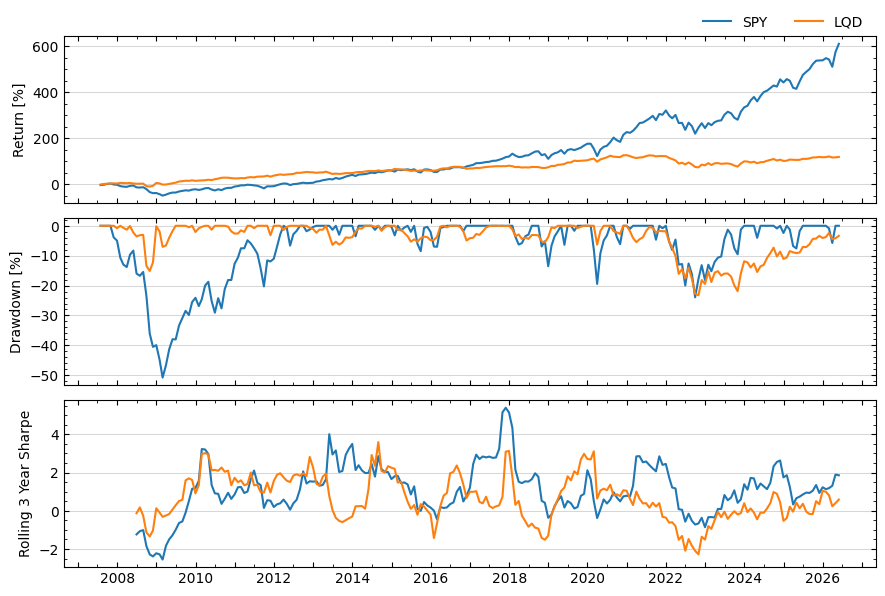

In [47]:
_ = performance_report(returns[['SPY', 'LQD']], risk_free_returns=returns['BIL'])

### Simple Portfolio of Stocks (SPY) and Bonds (LQD)

In [6]:
portfolio_name    = 'STOCK_BOND'
portfolio_weights = {'SPY' : 0.6,
                     'LQD' : 0.4,
                     }

if sum(list(portfolio_weights.values())) != 1:
    raise ValueError('Portfolio weights don\'t sum to 1!')

portfolio_returns = returns.mul(pd.Series(portfolio_weights)).sum(axis=1)
portfolio_returns = pd.DataFrame(portfolio_returns, columns=[portfolio_name])

stock_bond_df = returns[['SPY', 'LQD']].copy()
stock_bond_df = stock_bond_df.join(portfolio_returns)

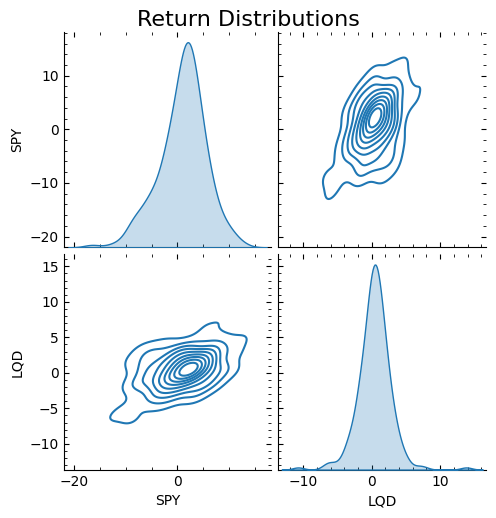

In [7]:
g = sns.pairplot(returns[['SPY', 'LQD']] * 100., kind='kde')
g.fig.suptitle('Return Distributions', y=1.02)
plt.show()